# logistic Regression
> with polynomial features

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions


In [21]:
df = pd.read_csv('ushape.csv')
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


In [22]:
# features and input
x = df.iloc[:,0:2]
y = df.iloc[:, -1]

In [23]:
# data split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

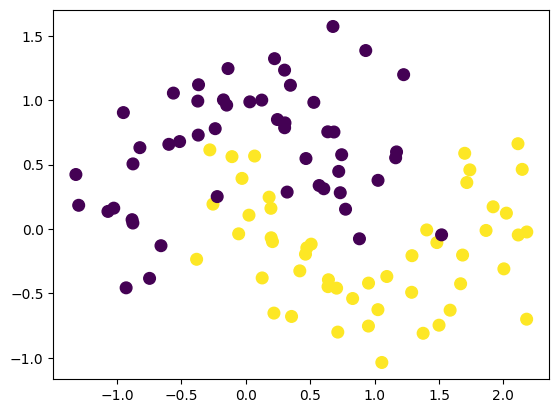

In [24]:
# actual data points
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=y, s = 70)
plt.show()

In [25]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

y_pred = lr.predict(x_test)

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


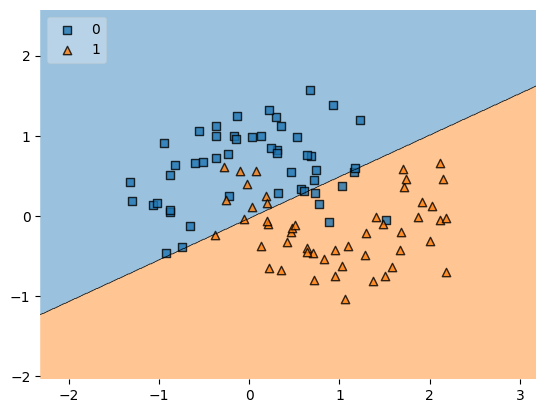

In [26]:
x = x.to_numpy()
y = y.to_numpy()

plot_decision_regions(x, y.astype(int), clf=lr, legend=2)
plt.show()

In [27]:
# accuracy score
from sklearn.metrics import accuracy_score
print('accuracy_score: ', accuracy_score(y_test, y_pred))

accuracy_score:  0.9


In [28]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(lr,x_train,y_train,scoring='accuracy',cv = 10))

np.float64(0.8)

## Polynomial Features

In [29]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3, include_bias= False)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [30]:
lr_new = LogisticRegression()
lr_new.fit(x_train_trans, y_train)

LogisticRegression()

In [31]:
y_pred_new = lr_new.predict(x_test_trans)
print('accuracy_score: ',accuracy_score(y_test, y_pred_new))

accuracy_score:  0.95


In [32]:
np.mean(cross_val_score(lr_new,x_train_trans,y_train,scoring='accuracy',cv = 10))

np.float64(0.9)

In [33]:
def plot_decision_boundary(X,y,degree=1):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    clf = LogisticRegression()
    clf.fit(X_trf,y)
    
    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

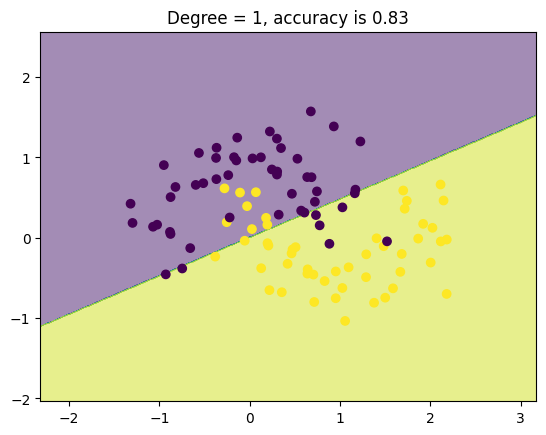

In [35]:
plot_decision_boundary(x,y)

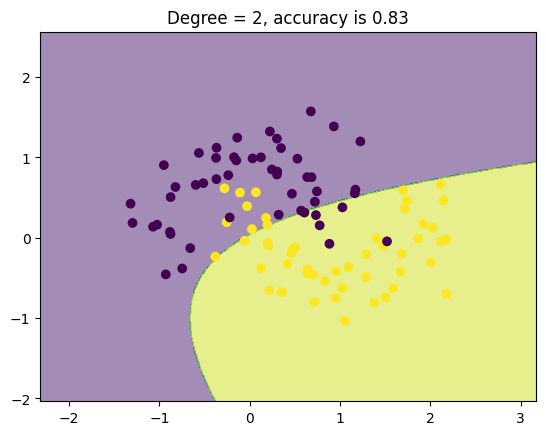

In [36]:
plot_decision_boundary(x,y,degree=2)

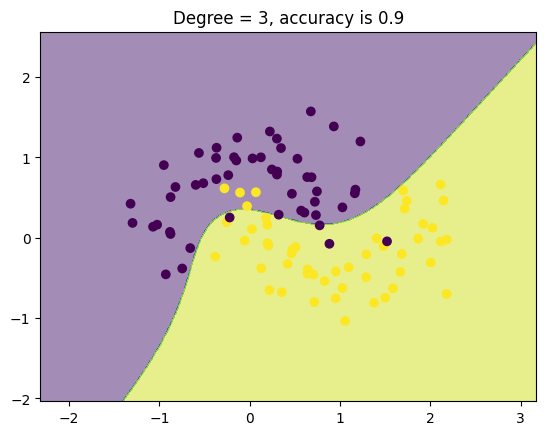

In [37]:
plot_decision_boundary(x,y,degree=3)

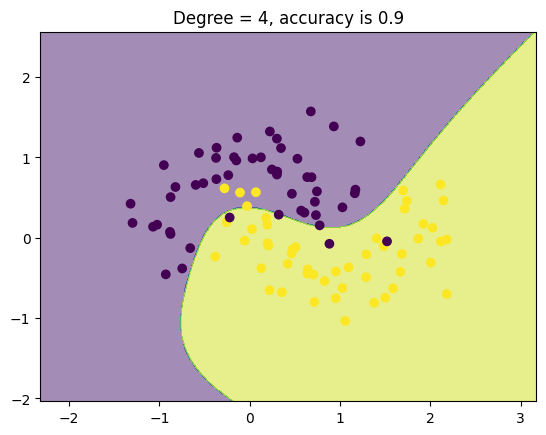

In [38]:
plot_decision_boundary(x,y,degree=4)

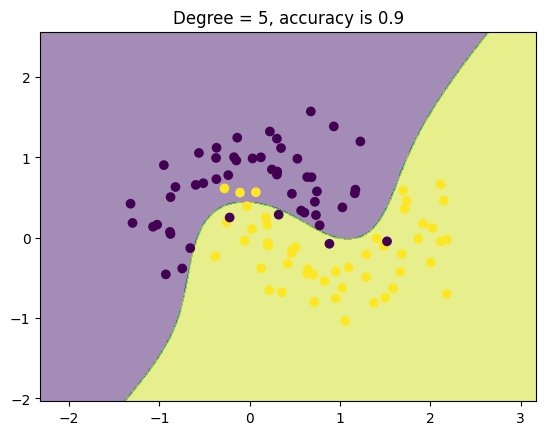

In [39]:
plot_decision_boundary(x,y,degree=5)